# Análisis Exploratorio de Datos - Mercado Inmobiliario Airbnb
**Actividad Evaluable - Fase 1: EDA**

**Nombre:** Ana Sarai Zuñiga Esquivel.
**Fecha:** Abril 2026
**Dataset:** Airbnb Price Prediction (Kaggle)

---

## Introducción
En este notebook realize un análisis exploratorio de datos (EDA) sobre el mercado inmobiliario de Airbnb. El objetivo es entender la distribución de los datos, identificar variables clave que afectan el precio, y detectar posibles anomalías o patrones relevantes.

Dataset: https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction

---
## Parte 1: Carga de datos e importación de librerías

In [ ]:
!pip install seaborn

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Librerías importadas correctamente')
print(f'pandas  v{pd.__version__}')
print(f'numpy   v{np.__version__}')
print(f'seaborn v{sns.__version__}')

Librerías importadas correctamente
pandas  v3.0.1
numpy   v2.4.3
seaborn v0.13.2


In [4]:
# Carga del dataset
# Descargar desde: https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction
# Colocar train.csv en la misma carpeta que este notebook

df = pd.read_csv('train.csv', low_memory=False)

print('Dataset cargado sin errores')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

Dataset cargado sin errores
Filas:    74,111
Columnas: 29


In [5]:
# Primer vistazo
df.head(10)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
5,12422935,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2,1.0,Real Bed,strict,True,...,37.753164,-122.429526,Comfort Suite San Francisco,Noe Valley,3,100.0,https://a0.muscache.com/im/pictures/82509143-4...,94131,1.0,1.0
6,11825529,4.418841,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",3,1.0,Real Bed,moderate,True,...,33.980454,-118.462821,Beach Town Studio and Parking!!!11h,NaN,15,97.0,https://a0.muscache.com/im/pictures/4c920c60-4...,90292,1.0,1.0
7,13971273,4.787492,Condominium,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Wheelchair...",2,1.0,Real Bed,moderate,True,...,34.046737,-118.260439,"Near LA Live, Staple's. Starbucks inside. OWN ...",Downtown,9,93.0,https://a0.muscache.com/im/pictures/61bd05d5-c...,90015,1.0,1.0
8,180792,4.787492,House,Private room,"{TV,""Cable TV"",""Wireless Internet"",""Pets live ...",2,1.0,Real Bed,moderate,True,...,37.781128,-122.501095,Cozy Garden Studio - Private Entry,Richmond District,159,99.0,https://a0.muscache.com/im/pictures/0ed6c128-7...,94121,1.0,1.0
9,5385260,3.583519,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",2,1.0,Real Bed,moderate,True,...,33.992563,-117.895997,No.7 Queen Size Cozy Room 舒适大床房,NaN,2,90.0,https://a0.muscache.com/im/pictures/8d2f08ce-b...,91748,1.0,1.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-null  str    
 

In [7]:
# Preparación de la variable precio
# El dataset usa log_price como target; la convertimos a precio real
if 'log_price' in df.columns:
    df['price'] = np.exp(df['log_price'])
    print('Columna price creada desde log_price')
elif 'price' in df.columns:
    if df['price'].dtype == object:
        df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
    print('Columna price disponible directamente')

print(f'Min: ${df["price"].min():.2f} | Max: ${df["price"].max():.2f}')
print(f'Media: ${df["price"].mean():.2f} | Mediana: ${df["price"].median():.2f}')

Columna price creada desde log_price
Min: $1.00 | Max: $1999.00
Media: $160.37 | Mediana: $111.00


---
## Parte 2: Análisis Exploratorio de Datos (EDA)
### 2.1 Análisis Descriptivo

In [8]:
# Estadísticas descriptivas generales
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,74111.0,11266617.10,6081734.89,344.00,6261964.50,12254147.00,16402260.50,21230903.00
log_price,74111.0,4.78,0.72,0.00,4.32,4.71,5.22,7.60
accommodates,74111.0,3.16,2.15,1.00,2.00,2.00,4.00,16.00
bathrooms,73911.0,1.24,0.58,0.00,1.00,1.00,1.00,8.00
latitude,74111.0,38.45,3.08,33.34,34.13,40.66,40.75,42.39
longitude,74111.0,-92.40,21.71,-122.51,-118.34,-77.00,-73.95,-70.99
number_of_reviews,74111.0,20.90,37.83,0.00,1.00,6.00,23.00,605.00
review_scores_rating,57389.0,94.07,7.84,20.00,92.00,96.00,100.00,100.00
bedrooms,74020.0,1.27,0.85,0.00,1.00,1.00,1.00,10.00
beds,73980.0,1.71,1.25,0.00,1.00,1.00,2.00,18.00


In [9]:
# Estadísticas univariadas: media, mediana, moda, desviación estándar
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

stats = []
for col in num_cols:
    stats.append({
        'Variable':       col,
        'Media':          round(df[col].mean(), 3),
        'Mediana':        round(df[col].median(), 3),
        'Moda':           round(df[col].mode()[0], 3) if not df[col].mode().empty else None,
        'Desv. Std':      round(df[col].std(), 3),
        'Mínimo':         round(df[col].min(), 3),
        'Máximo':         round(df[col].max(), 3),
        'Asimetría':      round(df[col].skew(), 3),
        'Valores Nulos':  int(df[col].isnull().sum())
    })

pd.DataFrame(stats).set_index('Variable')

,Media,Mediana,Moda,Desv. Std,Mínimo,Máximo,Asimetría,Valores Nulos
Variable,,,,,,,,
id,1.126662e+07,1.225415e+07,344.000,6081734.887,344.000,2.123090e+07,-0.261,0
log_price,4.782000e+00,4.710000e+00,5.011,0.717,0.000,7.600000e+00,0.515,0
accommodates,3.155000e+00,2.000000e+00,2.000,2.154,1.000,1.600000e+01,2.232,0
bathrooms,1.235000e+00,1.000000e+00,1.000,0.582,0.000,8.000000e+00,3.691,200
latitude,3.844600e+01,4.066200e+01,33.339,3.080,33.339,4.239000e+01,-0.535,0
longitude,-9.239800e+01,-7.699700e+01,-122.511,21.705,-122.511,-7.098500e+01,-0.407,0
number_of_reviews,2.090100e+01,6.000000e+00,0.000,37.829,0.000,6.050000e+02,3.703,0
review_scores_rating,9.406700e+01,9.600000e+01,100.000,7.837,20.000,1.000000e+02,-3.381,16722
bedrooms,1.266000e+00,1.000000e+00,1.000,0.852,0.000,1.000000e+01,1.990,91


In [10]:
# Valores nulos
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Total': (df.isnull().mean() * 100).round(2)
})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
print('=== Valores Nulos ===')
print(null_df.to_string() if not null_df.empty else 'No hay valores nulos.')

=== Valores Nulos ===
                        Nulos  % Total
host_response_rate      18299    24.69
review_scores_rating    16722    22.56
first_review            15864    21.41
last_review             15827    21.36
thumbnail_url            8216    11.09
neighbourhood            6872     9.27
zipcode                   966     1.30
bathrooms                 200     0.27
host_has_profile_pic      188     0.25
host_identity_verified    188     0.25
host_since                188     0.25
beds                      131     0.18
bedrooms                   91     0.12


In [11]:
# Correlación con el precio: identificación de variables clave
correlaciones = df[num_cols].corr()['price'].drop('price').abs().sort_values(ascending=False)
print('=== Correlación Absoluta con el Precio (Top 10) ===')
print(correlaciones.head(10).to_string())
print('\nEstas son las variables candidatas a ser más influyentes en el precio.')

=== Correlación Absoluta con el Precio (Top 10) ===
log_price               0.840001
accommodates            0.519326
bedrooms                0.494437
bathrooms               0.459350
beds                    0.433162
number_of_reviews       0.070956
review_scores_rating    0.067100
longitude               0.057601
latitude                0.031344
id                      0.002698

Estas son las variables candidatas a ser más influyentes en el precio.


In [12]:
# Variables categóricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categóricas ({len(cat_cols)}):' )
for col in cat_cols:
    n_u = df[col].nunique()
    top = df[col].value_counts().index[0]
    pct = df[col].value_counts(normalize=True).values[0] * 100
    print(f'  {col:<30} | {n_u:>4} únicos | Top: "{top}" ({pct:.1f}%)')

Variables categóricas (18):
  property_type                  |   35 únicos | Top: "Apartment" (66.1%)
  room_type                      |    3 únicos | Top: "Entire home/apt" (55.7%)
  amenities                      | 67122 únicos | Top: "{}" (0.8%)
  bed_type                       |    5 únicos | Top: "Real Bed" (97.2%)
  cancellation_policy            |    5 únicos | Top: "strict" (43.7%)
  city                           |    6 únicos | Top: "NYC" (43.6%)
  description                    | 73479 únicos | Top: "Hello, I've been running guest house for Koreans visiting U.S. for 3years, and recently decided to run this place for other travelers also. There are 10 room in the house. They are mostly dormitory rooms and couple of couple room and family room. This places are our women's dormitory in third floor. There are three rooms, but no doors. It is basically open space. There are 2 beds in two rooms and 4 in one room. I do not have closet in this room but there are hangers and mini she

---
### 2.2 Visualización de Datos
#### A) Histogramas

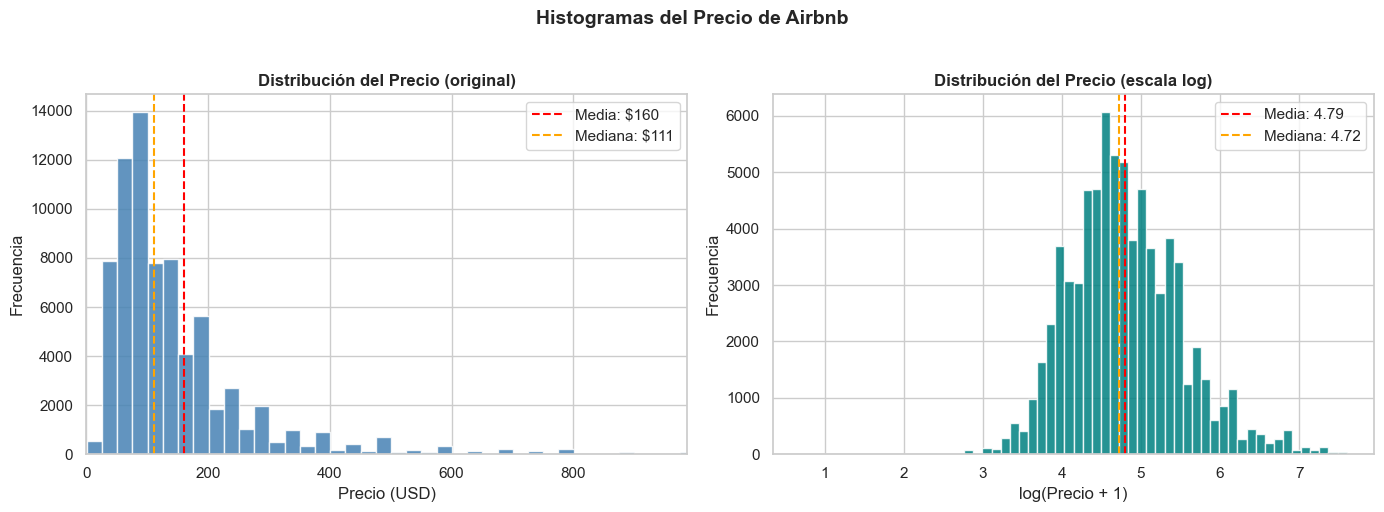

Observación: El precio tiene distribución muy sesgada a la derecha.
La transformación logarítmica produce una distribución más simétrica,
lo cual es conveniente para modelos de regresión.


In [13]:
# Histograma del precio (original y escala log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Precio (original)', fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['price'].mean(),   color='red',    linestyle='--', label=f'Media: ${df["price"].mean():.0f}')
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["price"].median():.0f}')
axes[0].set_xlim(0, df['price'].quantile(0.99))
axes[0].legend()

log_p = np.log1p(df['price'].dropna())
axes[1].hist(log_p, bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución del Precio (escala log)', fontweight='bold')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(log_p.mean(),   color='red',    linestyle='--', label=f'Media: {log_p.mean():.2f}')
axes[1].axvline(log_p.median(), color='orange', linestyle='--', label=f'Mediana: {log_p.median():.2f}')
axes[1].legend()

plt.suptitle('Histogramas del Precio de Airbnb', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observación: El precio tiene distribución muy sesgada a la derecha.')
print('La transformación logarítmica produce una distribución más simétrica,')
print('lo cual es conveniente para modelos de regresión.')

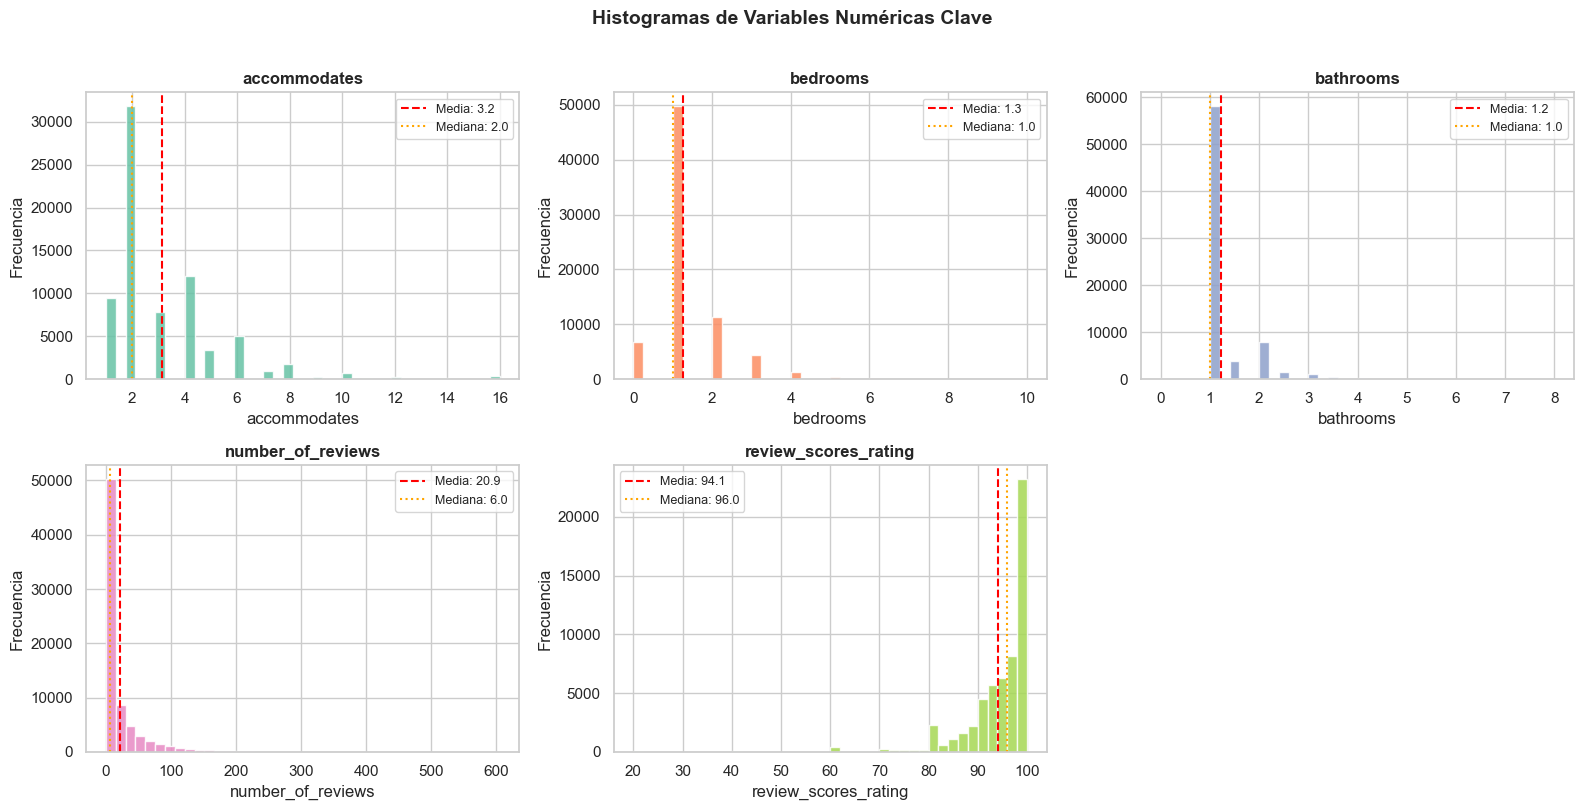

In [14]:
# Histogramas de otras variables importantes
vars_hist = [c for c in ['accommodates','bedrooms','bathrooms',
                          'number_of_reviews','review_scores_rating','availability_365']
             if c in df.columns]

cols_g = 3
rows_g = (len(vars_hist) + cols_g - 1) // cols_g
fig, axes = plt.subplots(rows_g, cols_g, figsize=(16, rows_g * 4))
axes = axes.flatten()
pal  = sns.color_palette('Set2', len(vars_hist))

for i, col in enumerate(vars_hist):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color=pal[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle=':',  label=f'Mediana: {data.median():.1f}')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Histogramas de Variables Numéricas Clave', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### B) Box Plots – Identificación de Outliers

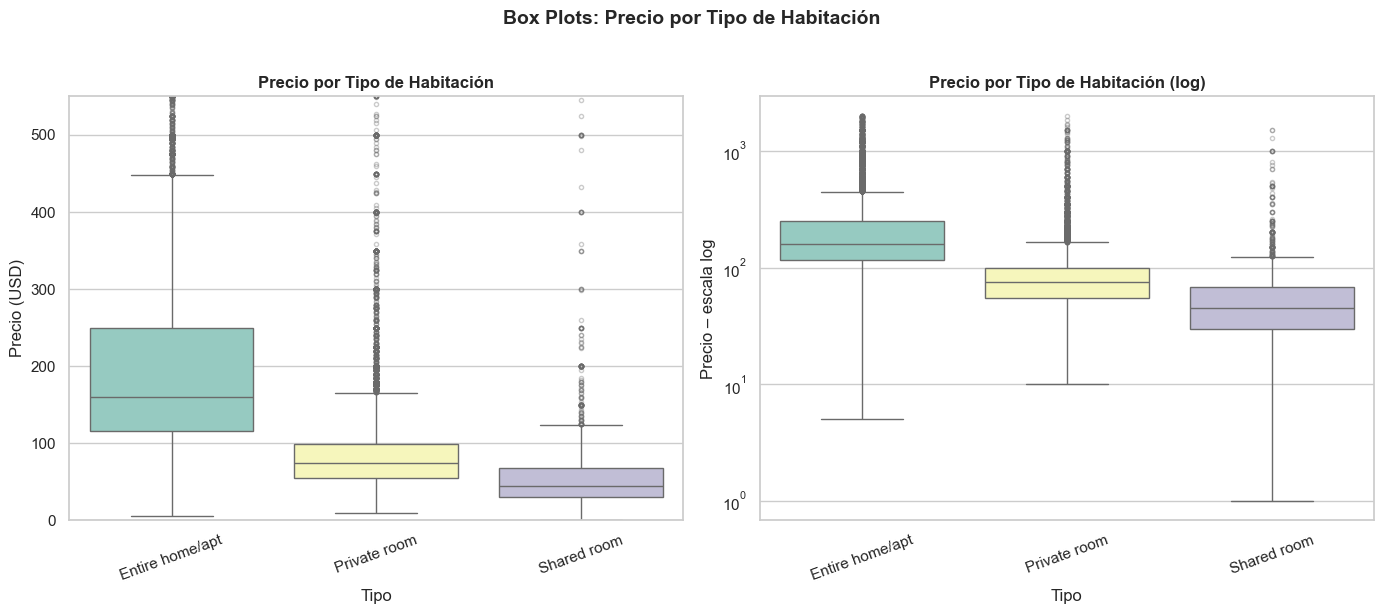

Observación: "Entire home/apt" tiene el precio mediano más alto.
Todos los tipos presentan outliers hacia valores altos.


In [15]:
# Box plot: precio por tipo de habitación
if 'room_type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
    fp = dict(marker='o', markersize=3, alpha=0.35, color='gray')

    sns.boxplot(data=df, x='room_type', y='price', order=order, palette='Set3', ax=axes[0], flierprops=fp)
    axes[0].set_ylim(0, df['price'].quantile(0.97))
    axes[0].set_title('Precio por Tipo de Habitación', fontweight='bold')
    axes[0].set_xlabel('Tipo'); axes[0].set_ylabel('Precio (USD)')
    axes[0].tick_params(axis='x', rotation=20)

    sns.boxplot(data=df, x='room_type', y='price', order=order, palette='Set3', ax=axes[1], flierprops=fp)
    axes[1].set_yscale('log')
    axes[1].set_title('Precio por Tipo de Habitación (log)', fontweight='bold')
    axes[1].set_xlabel('Tipo'); axes[1].set_ylabel('Precio – escala log')
    axes[1].tick_params(axis='x', rotation=20)

    plt.suptitle('Box Plots: Precio por Tipo de Habitación', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('Observación: "Entire home/apt" tiene el precio mediano más alto.')
    print('Todos los tipos presentan outliers hacia valores altos.')

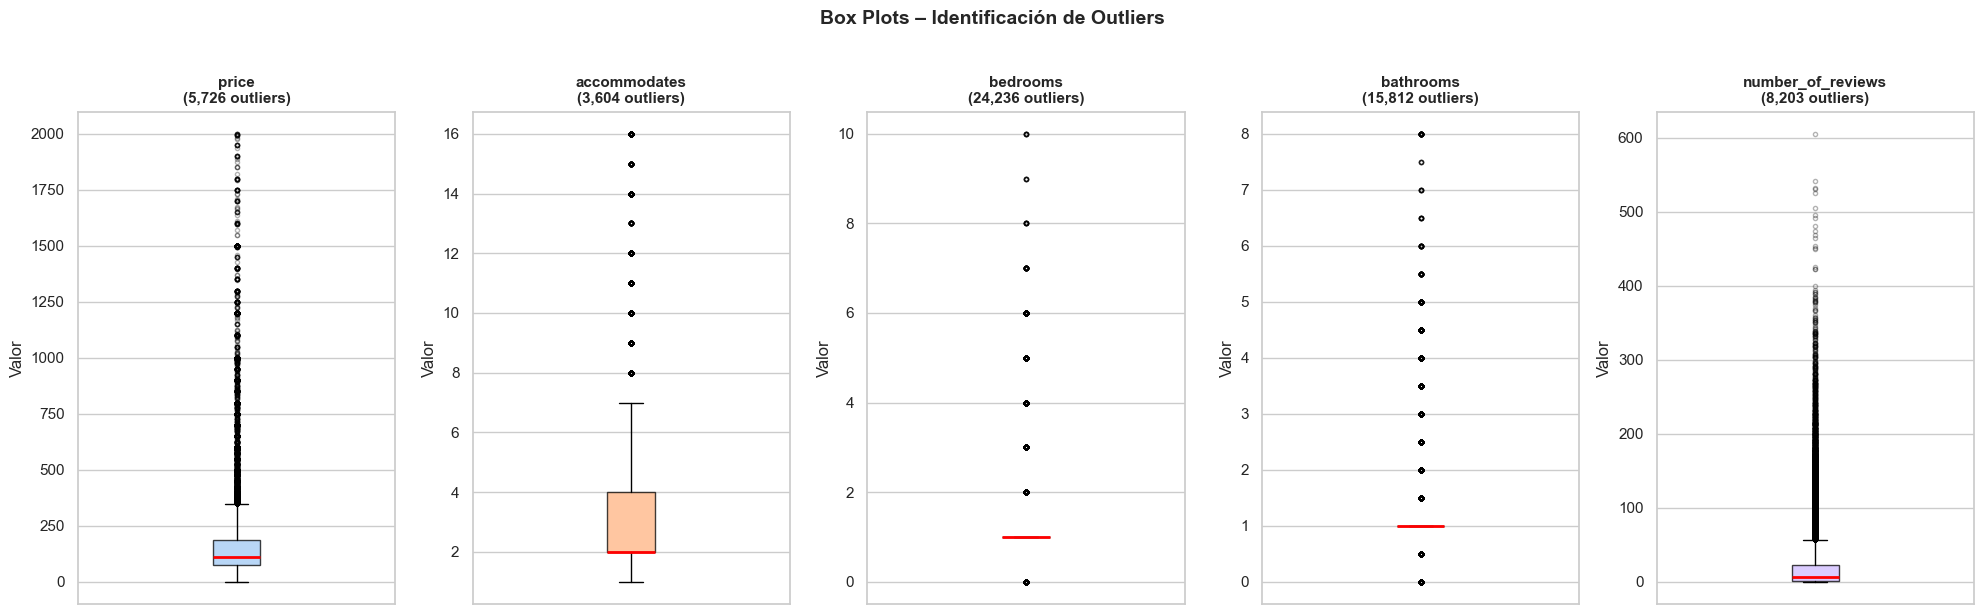

Observación: El precio y el número de reseñas tienen gran cantidad de outliers superiores.
Esto indica distribuciones con colas largas que requieren tratamiento.


In [16]:
# Box plots generales para detectar outliers en variables numéricas clave
vars_box = [c for c in ['price','accommodates','bedrooms','bathrooms','number_of_reviews']
            if c in df.columns]

fig, axes = plt.subplots(1, len(vars_box), figsize=(4*len(vars_box), 6))
if len(vars_box) == 1: axes = [axes]
pal_b = sns.color_palette('pastel', len(vars_box))

for i, col in enumerate(vars_box):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    n_out  = int(((df[col] < q1-1.5*(q3-q1)) | (df[col] > q3+1.5*(q3-q1))).sum())
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=pal_b[i], alpha=0.75),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3, color='dimgray'))
    axes[i].set_title(f'{col}\n({n_out:,} outliers)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valor'); axes[i].set_xticks([])

plt.suptitle('Box Plots – Identificación de Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observación: El precio y el número de reseñas tienen gran cantidad de outliers superiores.')
print('Esto indica distribuciones con colas largas que requieren tratamiento.')

#### C) Scatter Plots – Relaciones entre Variables

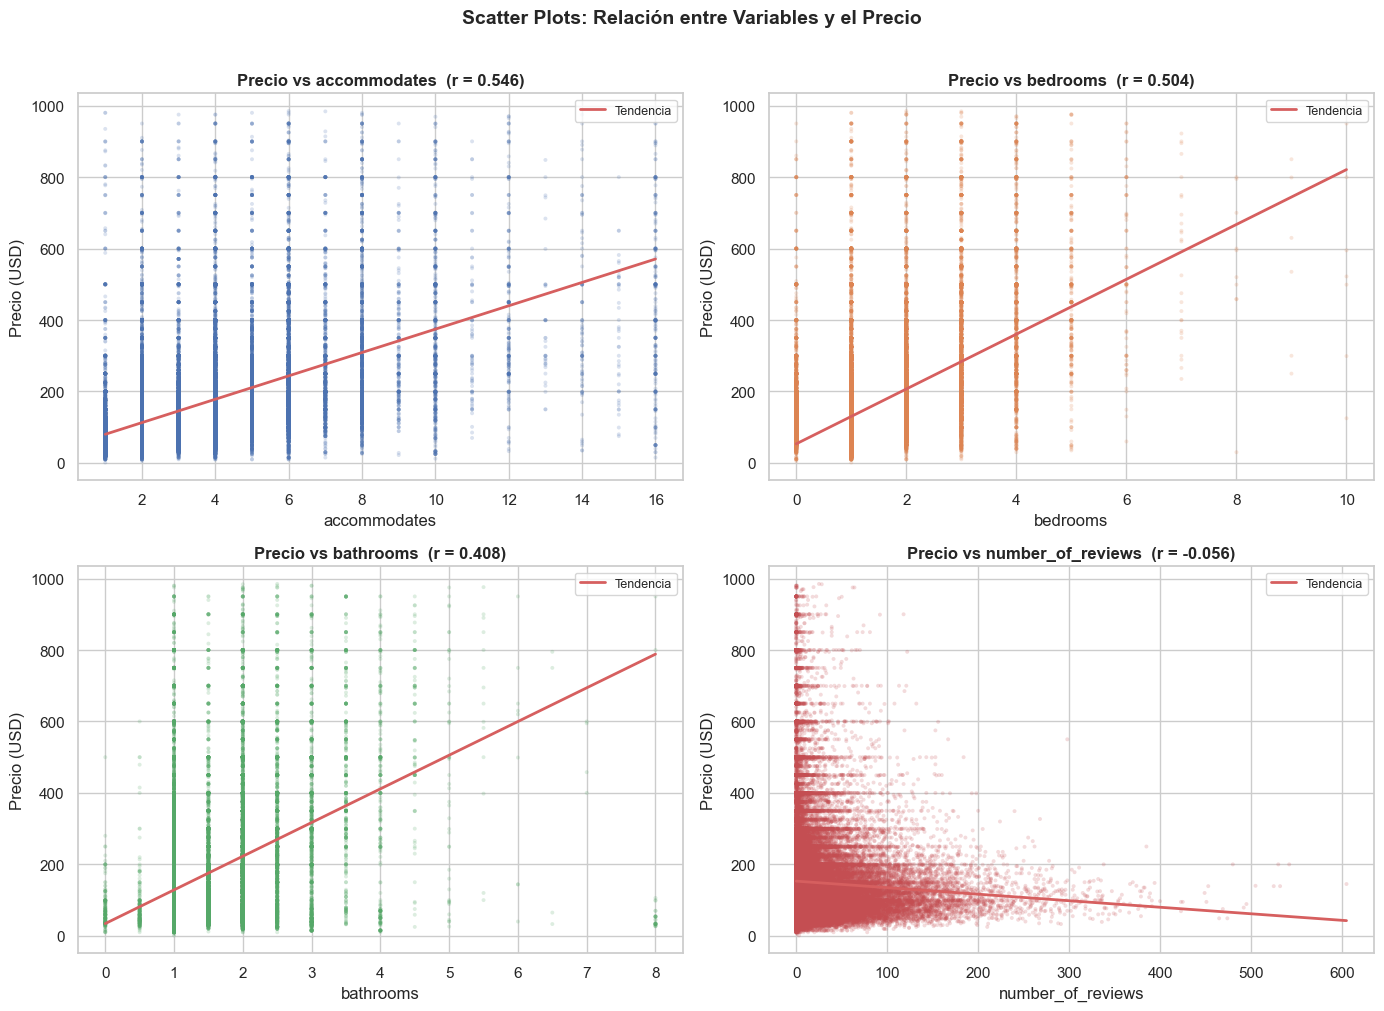

Observación: "accommodates" y "bedrooms" muestran la correlación positiva más clara.
A mayor capacidad del alojamiento, mayor es el precio esperado.


In [17]:
# Scatter plots: precio vs variables numéricas clave
sc_vars = [c for c in ['accommodates','bedrooms','bathrooms','number_of_reviews'] if c in df.columns]
df_plot = df[df['price'] < df['price'].quantile(0.99)].copy()

fig, axes = plt.subplots((len(sc_vars)+1)//2, 2, figsize=(14, ((len(sc_vars)+1)//2)*5))
axes = axes.flatten()
cols_sc = sns.color_palette('deep', len(sc_vars))

for i, var in enumerate(sc_vars):
    sub = df_plot[[var,'price']].dropna()
    axes[i].scatter(sub[var], sub['price'], alpha=0.2, s=8, color=cols_sc[i], edgecolors='none')
    z = np.polyfit(sub[var], sub['price'], 1)
    x_l = np.linspace(sub[var].min(), sub[var].max(), 100)
    axes[i].plot(x_l, np.poly1d(z)(x_l), 'r-', linewidth=2, label='Tendencia')
    corr = sub.corr().iloc[0,1]
    axes[i].set_title(f'Precio vs {var}  (r = {corr:.3f})', fontweight='bold')
    axes[i].set_xlabel(var); axes[i].set_ylabel('Precio (USD)')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Scatter Plots: Relación entre Variables y el Precio', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observación: "accommodates" y "bedrooms" muestran la correlación positiva más clara.')
print('A mayor capacidad del alojamiento, mayor es el precio esperado.')

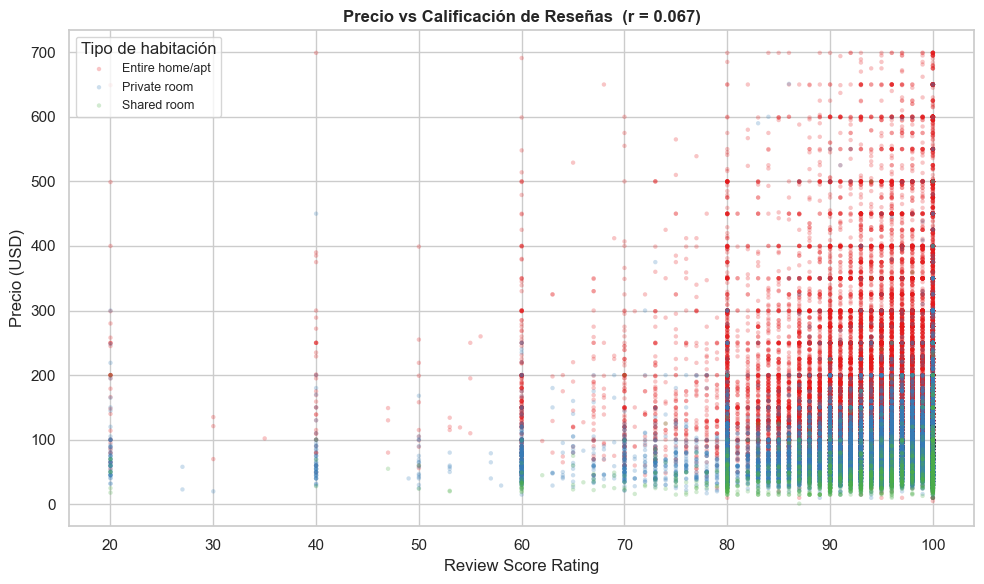

Observación: correlación precio-calificación = 0.067.
La puntuación de reseñas no es el principal determinante del precio.


In [18]:
# Scatter plot: precio vs calificación de reseñas
if 'review_scores_rating' in df.columns:
    df_rv = df.dropna(subset=['review_scores_rating','price'])
    df_rv = df_rv[df_rv['price'] < df_rv['price'].quantile(0.99)]

    fig, ax = plt.subplots(figsize=(10, 6))
    if 'room_type' in df.columns:
        for rt, color in zip(df_rv['room_type'].unique(), sns.color_palette('Set1')):
            s = df_rv[df_rv['room_type'] == rt]
            ax.scatter(s['review_scores_rating'], s['price'], alpha=0.25, s=10, color=color, label=rt, edgecolors='none')
        ax.legend(title='Tipo de habitación', fontsize=9)
    else:
        ax.scatter(df_rv['review_scores_rating'], df_rv['price'], alpha=0.25, s=10, color='steelblue', edgecolors='none')

    corr_rv = df_rv[['review_scores_rating','price']].corr().iloc[0,1]
    ax.set_title(f'Precio vs Calificación de Reseñas  (r = {corr_rv:.3f})', fontweight='bold')
    ax.set_xlabel('Review Score Rating'); ax.set_ylabel('Precio (USD)')
    plt.tight_layout()
    plt.show()

    print(f'Observación: correlación precio-calificación = {corr_rv:.3f}.')
    print('La puntuación de reseñas no es el principal determinante del precio.')

#### D) Mapa de Calor de Correlaciones

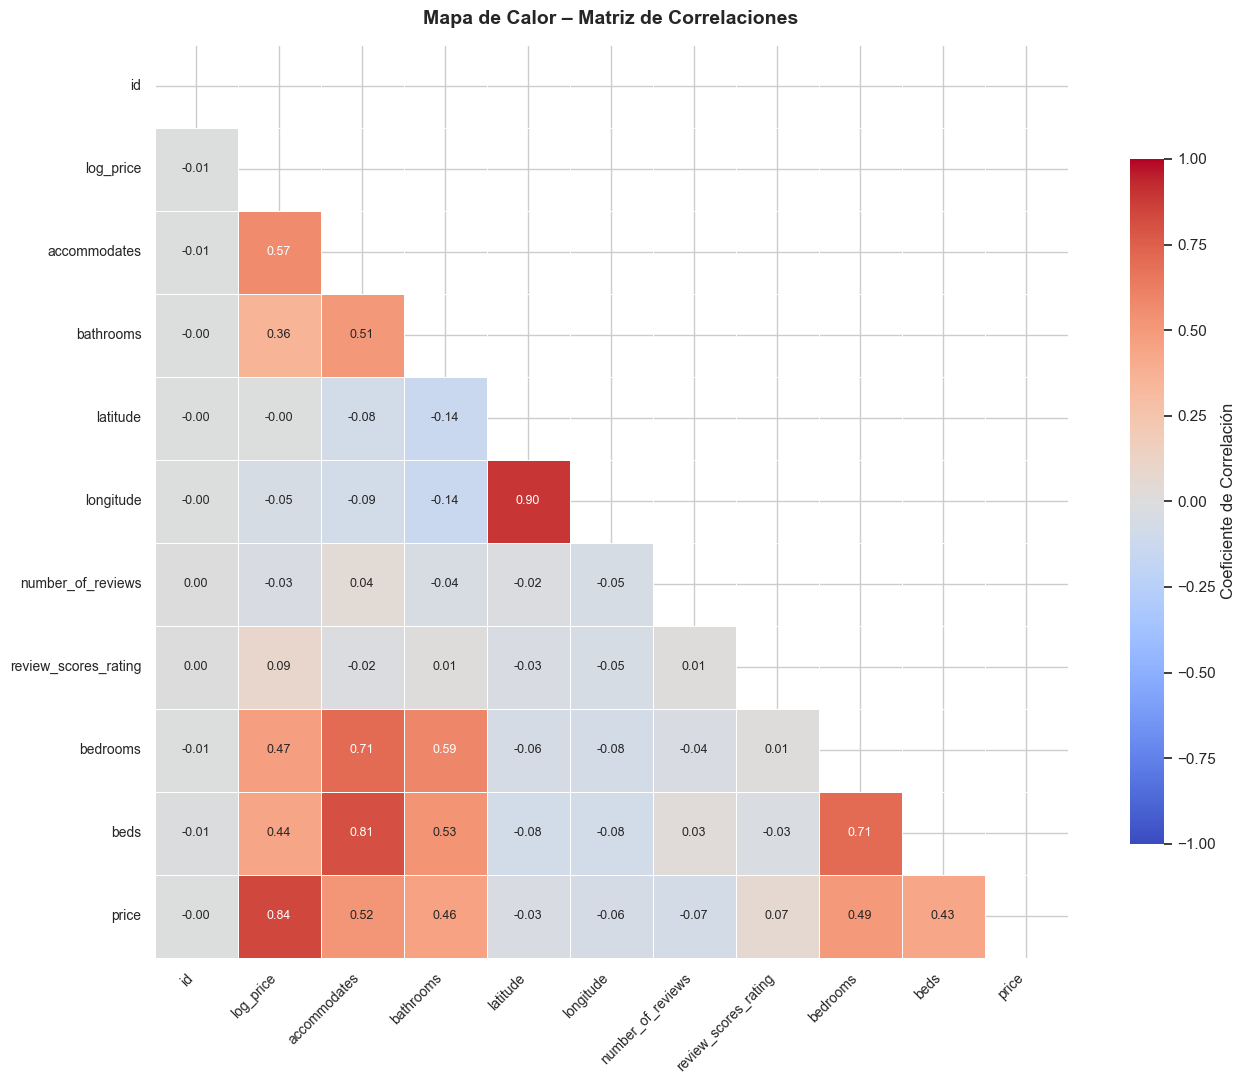

Observación: Se observan altas correlaciones entre variables de tamaño
(accommodates, bedrooms, bathrooms), lo que indica posible multicolinealidad.


In [19]:
# Mapa de calor de correlaciones entre variables numéricas
num_df_hm   = df[num_cols].loc[:, df[num_cols].isnull().mean() < 0.5]
corr_matrix = num_df_hm.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75, 'label': 'Coeficiente de Correlación'},
            ax=ax, annot_kws={'size': 9})

ax.set_title('Mapa de Calor – Matriz de Correlaciones', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print('Observación: Se observan altas correlaciones entre variables de tamaño')
print('(accommodates, bedrooms, bathrooms), lo que indica posible multicolinealidad.')

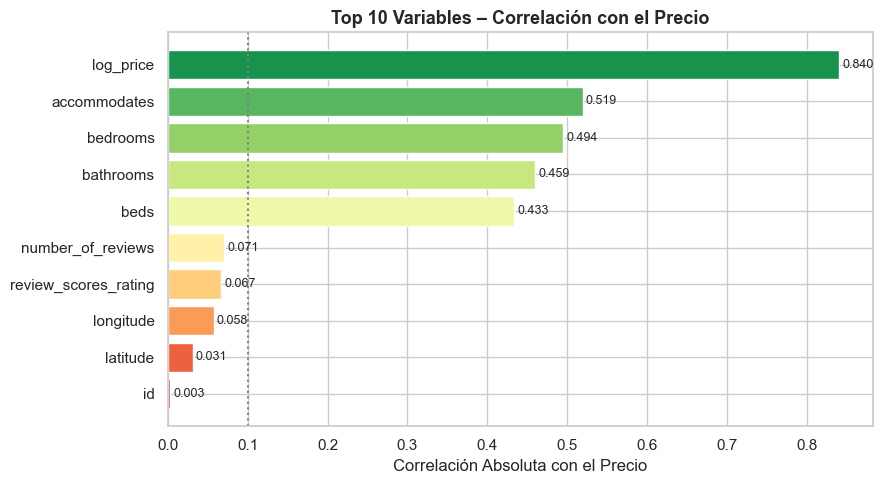

In [20]:
# Gráfico: Top 10 variables más correlacionadas con el precio
top_corr = corr_matrix['price'].abs().sort_values(ascending=False).drop('price').head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1],
               color=sns.color_palette('RdYlGn_r', len(top_corr))[::-1])
ax.set_xlabel('Correlación Absoluta con el Precio', fontsize=12)
ax.set_title('Top 10 Variables – Correlación con el Precio', fontsize=13, fontweight='bold')
ax.axvline(0.1, color='gray', linestyle=':', linewidth=1.5)

for bar, val in zip(bars, top_corr.values[::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### E) Análisis adicional: Precio por Ciudad y Tipo de Propiedad

=== Precio por Ciudad ===
          Media  Mediana  Conteo
city                            
SF       227.37    165.0    6434
DC       217.93    125.0    5688
Boston   165.63    136.0    3468
LA       155.39    100.0   22453
NYC      143.02    105.0   32349
Chicago  132.48     99.0    3719


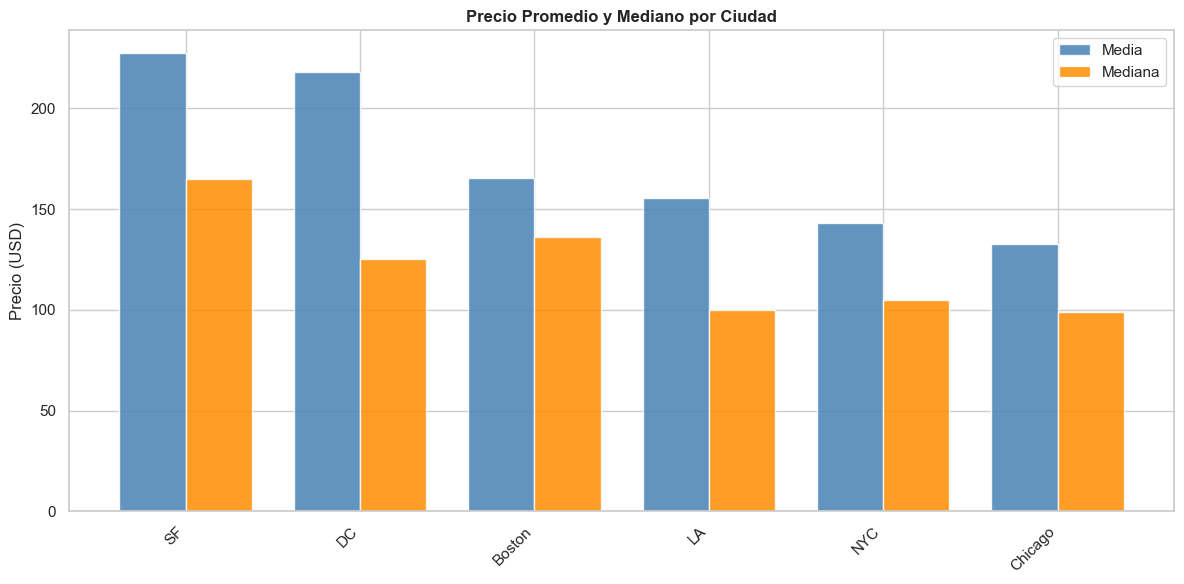

Observación: La ubicación geográfica es determinante del precio.
La brecha media-mediana refleja outliers altos en cada ciudad.


In [21]:
# Precio por ciudad
if 'city' in df.columns:
    precio_ciudad = df.groupby('city')['price'].agg(Media='mean', Mediana='median', Conteo='count').sort_values('Media', ascending=False)
    print('=== Precio por Ciudad ==='); print(precio_ciudad.round(2).to_string())

    top15 = precio_ciudad.head(15)
    x, w  = np.arange(len(top15)), 0.38
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x-w/2, top15['Media'],   w, label='Media',   color='steelblue',  alpha=0.85)
    ax.bar(x+w/2, top15['Mediana'], w, label='Mediana', color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(top15.index, rotation=45, ha='right')
    ax.set_ylabel('Precio (USD)')
    ax.set_title('Precio Promedio y Mediano por Ciudad', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()

    print('Observación: La ubicación geográfica es determinante del precio.')
    print('La brecha media-mediana refleja outliers altos en cada ciudad.')

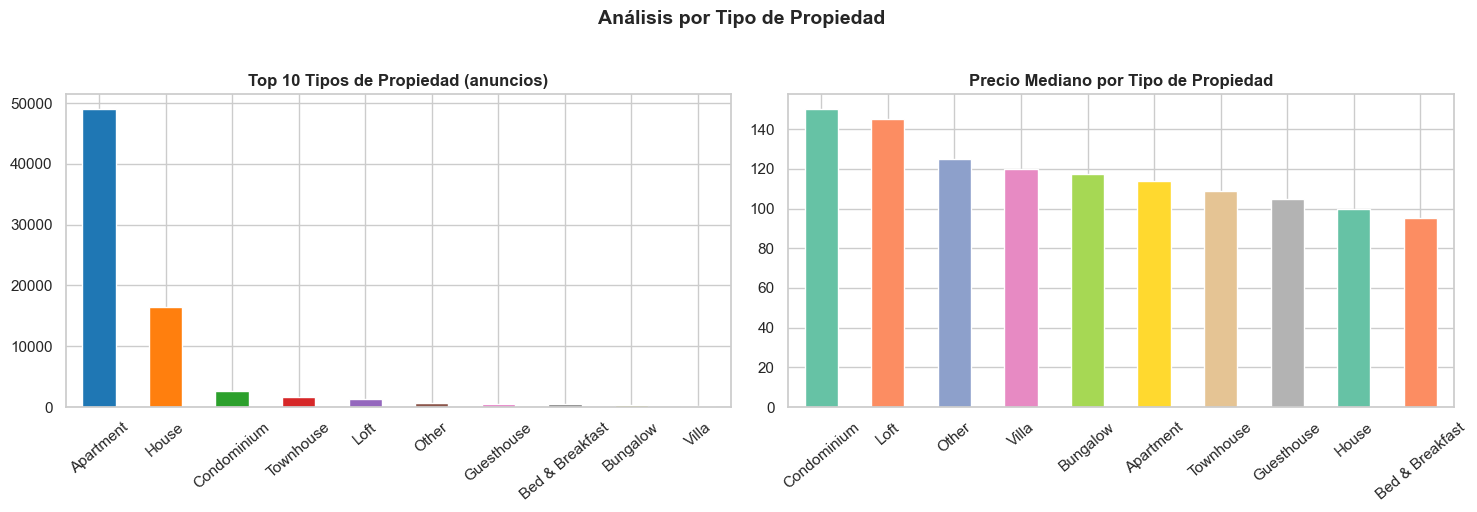

In [22]:
# Tipo de propiedad
if 'property_type' in df.columns:
    top_props = df['property_type'].value_counts().head(10)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    top_props.plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10',len(top_props)), edgecolor='white')
    axes[0].set_title('Top 10 Tipos de Propiedad (anuncios)', fontweight='bold')
    axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=40)

    precio_tipo = df[df['property_type'].isin(top_props.index)].groupby('property_type')['price'].median().sort_values(ascending=False)
    precio_tipo.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2',len(precio_tipo)), edgecolor='white')
    axes[1].set_title('Precio Mediano por Tipo de Propiedad', fontweight='bold')
    axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=40)

    plt.suptitle('Análisis por Tipo de Propiedad', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

---
## Interpretación y Hallazgos Documentados

In [23]:
print('=' * 65)
print('       RESUMEN DE HALLAZGOS – EDA AIRBNB')
print('=' * 65)

media   = df['price'].mean()
mediana = df['price'].median()
asim    = df['price'].skew()

print(f"""
1. DISTRIBUCIÓN DEL PRECIO
   Media: ${media:.2f}  |  Mediana: ${mediana:.2f}
   Asimetría: {asim:.2f} -> distribución sesgada a la derecha.
   Recomendación: usar log_price para modelado predictivo.

2. VARIABLES MÁS INFLUYENTES
   - 'accommodates' y 'bedrooms': mayor correlación positiva.
   - 'bathrooms': más baños implica mayor precio.
   - 'room_type': Entire home/apt > Private room > Shared room.
   - 'city': la ubicación introduce gran varianza en el precio.

3. OUTLIERS IDENTIFICADOS
   - Precios extremos (>$500/noche) presentes en todos los tipos.
   - 'number_of_reviews' también tiene outliers superiores.
   - Recomendación: winsorizing o filtrado en preprocesamiento.

4. VALORES NULOS
   - 'review_scores_rating' tiene datos faltantes.
   - Requiere imputación (media/mediana) en la siguiente fase.

5. MULTICOLINEALIDAD
   - accommodates, bedrooms y bathrooms están correlacionadas.
   - Evaluar regularización (Ridge/Lasso) o PCA.

6. PRÓXIMOS PASOS
   - Imputación de valores nulos.
   - Encoding de variables categóricas.
   - Feature engineering y selección de variables.
   - Construcción del modelo predictivo de precios.
""")
print('=' * 65)

       RESUMEN DE HALLAZGOS – EDA AIRBNB

1. DISTRIBUCIÓN DEL PRECIO
   Media: $160.37  |  Mediana: $111.00
   Asimetría: 4.30 -> distribución sesgada a la derecha.
   Recomendación: usar log_price para modelado predictivo.

2. VARIABLES MÁS INFLUYENTES
   - 'accommodates' y 'bedrooms': mayor correlación positiva.
   - 'bathrooms': más baños implica mayor precio.
   - 'room_type': Entire home/apt > Private room > Shared room.
   - 'city': la ubicación introduce gran varianza en el precio.

3. OUTLIERS IDENTIFICADOS
   - Precios extremos (>$500/noche) presentes en todos los tipos.
   - 'number_of_reviews' también tiene outliers superiores.
   - Recomendación: winsorizing o filtrado en preprocesamiento.

4. VALORES NULOS
   - 'review_scores_rating' tiene datos faltantes.
   - Requiere imputación (media/mediana) en la siguiente fase.

5. MULTICOLINEALIDAD
   - accommodates, bedrooms y bathrooms están correlacionadas.
   - Evaluar regularización (Ridge/Lasso) o PCA.

6. PRÓXIMOS PASOS
   -

---
## Conclusión

Este análisis exploratorio me permitió entender en profundidad la estructura y características del dataset de Airbnb. Los hallazgos principales son:

- **El precio está fuertemente sesgado** hacia la derecha; la transformación logarítmica es necesaria para el modelado.
- **Las variables de tamaño** (`accommodates`, `bedrooms`, `bathrooms`) son los mejores predictores numéricos del precio.
- **El tipo de habitación y la ubicación** son las variables categóricas más influyentes.
- **Existen outliers** significativos que deberán gestionarse antes del modelado.
- **La multicolinealidad** entre variables de tamaño requerirá atención durante el modelado.

---
